# Profiling in PyTorch

This notebook follows the [Profiling in PyTorch](https://huggingface.co/blog/torch-profiler) Hugging Face tutorial. 
All results were obtained on a laptopn with the following configuration:
* CPU: 13th Gen Intel(R) Core(TM) i7-13700HX
* GPU: NVIDIA GeForce RTX 4060 Max-Q / Mobile
* RAM: 32GiB SODIMM Synchronous 4800 MHz

In [1]:
import matplotlib.pyplot as plt
import os
import torch

## Part 1: A Beginner's Guide to `torch.profiler`

### Generating profiling tables and traces

The following code runs and profiles a function `fn` consisting of matrix multiplication and addition.

In [2]:
# Parameters
size = 4096
dtype = torch.bfloat16
compile_mode = None
warmup_steps = 10240 // size
profile_steps = 409600 // size
device = "cuda"
trace_dir = "./temp/01_matmul_add"
schedule_wait_steps = 1
schedule_warmup_steps = 1
schedule_active_steps = 3

# Function to be profiled (matrix multiplication and addition)
def fn(x, w, b):
    return torch.add(torch.matmul(x, w), b)

# Optionally compile it
fn = torch.compile(fn, mode=compile_mode) if compile_mode is not None else fn

# Annotate the function
def step():
    with torch.profiler.record_function("matmul_add"):
        return fn(x, w, b)

# Generate random inputs, weights, and biases
x = torch.randn(size, size, device=device, dtype=dtype)
w = torch.randn(size, size, device=device, dtype=dtype)
b = torch.randn(size, size, device=device, dtype=dtype)

# Optional warmup
if warmup_steps > 0:
    for _ in range(warmup_steps):
        step()
    torch.cuda.synchronize()

# Create the directory to store the trace
os.makedirs(trace_dir, exist_ok=True)

# Names for the trace files
tag = f"{size}_{dtype}_{warmup_steps}_{profile_steps}_{compile_mode}"
table_path = os.path.join(trace_dir, f"{tag}.txt")
trace_path = os.path.join(trace_dir, f"{tag}.json")

# Run profiling
schedule = torch.profiler.schedule(
    wait=schedule_wait_steps, 
    warmup=schedule_warmup_steps, 
    active=schedule_active_steps, 
    repeat=1)
with torch.profiler.profile(
    activities=[
        torch.profiler.ProfilerActivity.CPU,
        torch.profiler.ProfilerActivity.CUDA,
    ],
    schedule=schedule,
    record_shapes=False,
    profile_memory=False,
    with_stack=False,
) as prof:
    for _ in range(profile_steps):
        step()
        prof.step()
torch.cuda.synchronize()

# Save the traces
prof.export_chrome_trace(trace_path)
with open(table_path, "w") as f:
    f.write(prof.key_averages().table(sort_by="cuda_time_total", row_limit=15))

/home/florent/python_default_venv/lib/python3.12/site-packages/torch/profiler/profiler.py:217: UserWarning: Warning: Profiler clears events at the end of each cycle.Only events from the current cycle will be reported.To keep events across cycles, set acc_events=True.
  _warn_once(


Print the table of results:

In [3]:
with open(table_path, 'r') as f:
    print(f.read())

-------------------------------------------------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  
                                                   Name    Self CPU %      Self CPU   CPU total %     CPU total  CPU time avg     Self CUDA   Self CUDA %    CUDA total  CUDA time avg    # of Calls  
-------------------------------------------------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  
## Call CompiledFxGraph fp3o2sw6obdpsswqvoatof2vxkbq...         0.00%       0.000us         0.00%       0.000us       0.000us     321.501us       108.79%     321.501us     107.167us             3  
                                          ProfilerStep*         8.45%      38.169us        88.58%     399.982us     133.327us       0.000us         0.00%     295.517us      98.506us             3  
         

The following diagrams were generated by the Chrome trace viewer:

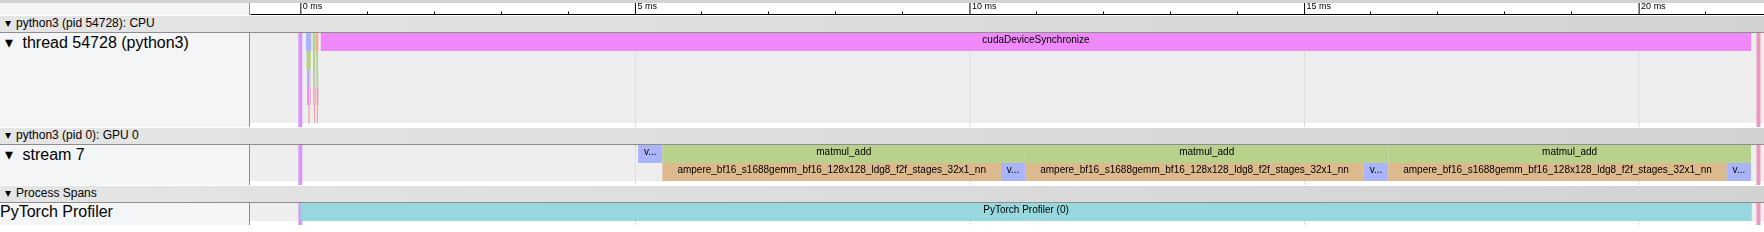
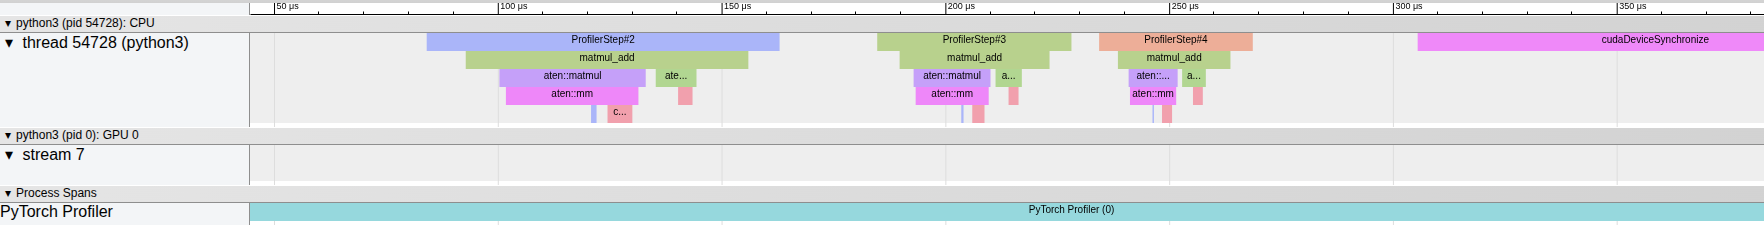

### GPU vs CPU runtime

Below we show the relative fraction of the total runtime spend on GPU as a function of the matrix size with the above parameters and different compilation modes. 
Note that the runtime can vary significantly between runs, so this plot should be taken with a grain of salt.

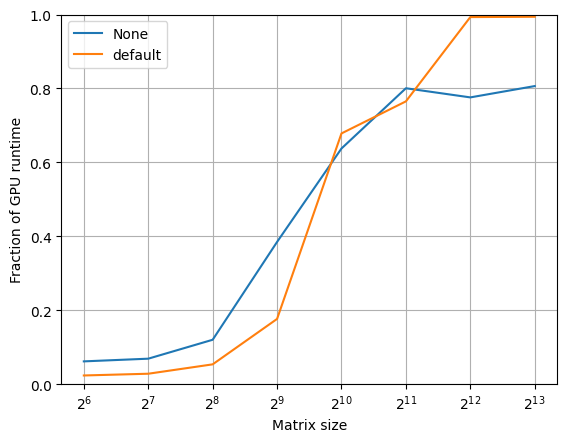

In [4]:
matrix_size = [64, 128, 256, 512, 1024, 2048, 4096, 8192]
cpu_runtime_microseconds_none = [159.604, 153.439, 161.030, 160.213, 313.910, 2707, 21421, 207402]
gpu_runtime_microseconds_none = [9.824, 10.560, 19.326, 61.632, 200.127, 2167, 16618, 167252]
cpu_runtime_microseconds_default = [422.540, 376.609, 361.342, 349.380, 436.184, 2613, 20966, 161898]
gpu_runtime_microseconds_default = [9.889, 10.590, 19.328, 61.632, 295.869, 1999, 20821, 160912]

gpu_runtime_fraction_none = [gpu_runtime_microseconds_none[i] / cpu_runtime_microseconds_none[i] for i in range(len(matrix_size))]
gpu_runtime_fraction_default = [gpu_runtime_microseconds_default[i] / cpu_runtime_microseconds_default[i] for i in range(len(matrix_size))]

plt.plot(matrix_size, gpu_runtime_fraction_none, label='None')
plt.plot(matrix_size, gpu_runtime_fraction_default, label='default')
plt.xlabel("Matrix size")
plt.ylabel("Fraction of GPU runtime")
plt.xscale('log', base=2)
plt.ylim(0,1)
plt.legend()
plt.grid()
plt.show()

Without compilation (mode `None`):
* For small matrices (dimensions below 256), most of the runtime is due to CPU operations (including data transfers to and from the GPU).
* The fraction of the runtime spent on GPU operations increases roughly lnearly in the matrix size between 256 and 2048.
* For larger matrices, about 80% of the runtime is spent on GPU.

Compilation with the `default` mode adds a fixed overhead of about 300µs to the CPU operations, making things worse for small matrices. However, it reduces the total CPU overhead for the largest sizes.